## Holdout Design Caution
* Julian Hsu 
* Date Created: 2026-06-16


The purpose of this script is to see how holdouts may not always lead to the correct launch decisions compared a shorter but equally allocated one.

**Takeaway**: Holdout and skewly allocated experiments don't always get you out of a short-term equally allocated one. Holdout experiments are where only a small part of traffic (usually 10%) gets either treatment and control. Holdout experiments can two or three times longer than the typical AB experiment. They seems really appealing particularly when making they are a part of a larger corporate strategy. 

Starting with a holdout experiment can be a waste of time. While you are running the experiment longer, you are further away from the 50-50 ideal to maximize precision. I simulated some YOLO-designed experiments (aka no power calculations) and found that doubling the duration and moving it to 90-10 allocation reduced the probability of launching a positive experiment. The holdout is only useful if the impact is large enough to offset the uneven treatment allocation. 

As a sidenote, I completely hand-wrote this notebook as a personal test. Sharing a few insights:
1. I can still do it!
2. This took probably x5 coding by hand.
3. It was easier to iterate coding by hand. Over time I saw how earlier requirements complicated the results, forcing me to simplify and ultimately create something better. 

In [1]:
## Import needed packages
import numpy as np
import pandas as pd
import statsmodels.api as sm

from matplotlib import gridspec
import matplotlib.pyplot as plt
%matplotlib inline  


## DGP and functions

In [189]:
def dgp(N=100, T=20):
    ## Let's simplify and assume outcomes across time periods are iid after we condition for some time effects
    y = np.random.normal(loc = 0, scale = 1, size = (N*T))
    unit_id = [ [e]*T for e in range(N) ]
    time_unit = np.array([np.arange(0,T)]*N).flatten()

    output_df = pd.DataFrame(data={'y': y, 'time': time_unit, 'unit_id': np.array(unit_id).flatten() }) 

    ## Adding some time effects for no good reason what so ever
    output_df['y'] += np.sin( np.abs( output_df['time'] ) )
    return output_df


def experiment_assignment_impact(data_input = None, p = 0.50, effect = 1 ):
    ## Assign treatment
    treatment_units = data_input['unit_id'].unique().tolist()

    treated_units = np.array(treatment_units)[ ( np.random.uniform(0,1,len(treatment_units)) <= p ) ]

    data_input['w'] = data_input['unit_id'].isin(treated_units)

    ## Apply treatment effect - make sure that this is dynamic 
    ## Use a logistic function that maxes out to effect  
    # modifier = 1 - 1/(1+np.exp(data_input['time'] - data_input['time'].mean() ))
    # data_input['y'] += data_input['w']*effect*modifier
    # data_input['y'] -= data_input['w']*(effect/2)

    data_input['y'] += data_input['w']*(effect)

    return data_input
    
def ttest(data_input):
    ## Extract the needed information
    ## Make sure that you take the total over each of the treatment groups at the unit_id level
    treatment_group = data_input[data_input['w'] == 1].groupby('unit_id').sum()
    control_group = data_input[data_input['w'] == 0].groupby('unit_id').sum()
    ttest, pval, dof = sm.stats.ttest_ind(treatment_group, control_group, usevar='unequal')
    diff = treatment_group.mean() - control_group.mean()
    return diff.values[0], pval[0]


In [190]:
## Simulate a decision:
def decide(diff_results):
    ## If treatment effect is positive and stat-sig then launch
    if (diff_results[0] >0) & (diff_results[1]< 0.05):
        return 1
    else:
        return 0


In [191]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Dumb test 
a = dgp(N = 100, T=20)
b = experiment_assignment_impact(a, p = 0.50, effect = 1 )
# ttest(b)


## Simulation.
We want three simulations:
1. Short-term experiment at 50-50 split
2. Long-term experiment at 50-50 split
3. Hold-out experiment at 90-10 split


In [192]:
## Unit test 
test_effect = 0.05
## Short-term experiment at 50-50
a = dgp()
b = experiment_assignment_impact(a, p = 0.50, effect =test_effect )
print( ttest(b.loc[b['time']<= 5]) ) 

## Long-term experiment at 50-50
a = dgp()
b = experiment_assignment_impact(a, p = 0.50, effect =test_effect)
print( ttest(b.loc[b['time']<= 10]) ) 

## Holdout experiment at 90-10
a = dgp()
b = experiment_assignment_impact(a, p = 0.10, effect =test_effect)
print( ttest(b.loc[b['time']<= 10]) ) 


(0.38191385047350024, 0.42718266727386867)
(0.5472380863448345, 0.4199714901988508)
(-0.3241598288277867, 0.6858714282523051)


In [193]:
sim_runs = 200 
test_effect = 0.1
time_horizon = 10
sample = 100
df_results = pd.DataFrame()
for s in range(sim_runs):
    ## Unit test 
    test_effect = 0.1
    ## Short-term experiment at 50-50
    a0 = dgp(N=sample, T=time_horizon)
    b0 = experiment_assignment_impact(a0, p = 0.50, effect =test_effect )
    c0= ttest(b0.loc[b0['time']<= 5]) 
    d0 = decide(c0)

    ## Long-term experiment at 50-50
    a1 = dgp(N=sample, T=time_horizon)
    b1 = experiment_assignment_impact(a1, p = 0.50, effect =test_effect)
    c1= ttest(b1.loc[b1['time']<= 10]) 
    d1= decide(c1)

    ## Holdout experiment at 90-10
    a2 = dgp(N=sample, T=time_horizon)
    b2 = experiment_assignment_impact(a2, p = 0.10, effect =test_effect)
    c2= ttest(b2.loc[b2['time']<= 10]) 
    d2= decide(c2)

    entry = {'diff_1':c0[0], 'diff_2':c1[0], 'diff_3':c2[0]
             , 'pval_1':c0[1], 'pval_2':c1[1], 'pval_3':c2[1]
             , 'launch_1':d0, 'launch_2':d1, 'launch_3':d2}
    df_entry = pd.DataFrame(entry, index = [s])
    df_results = pd.concat([df_results, df_entry], axis = 0)


In [194]:
print('How often do we launch?')
display( df_results[['launch_1','launch_2','launch_3']].mean() )

How often do we launch?


launch_1    0.245
launch_2    0.320
launch_3    0.140
dtype: float64

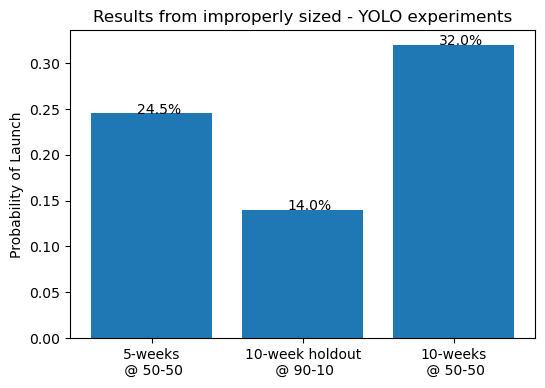

In [199]:
fix,ax = plt.subplots(ncols=1,nrows=1, figsize=(6,4))
ax.bar(['5-weeks\n @ 50-50', '10-week holdout\n @ 90-10', '10-weeks\n @ 50-50'], df_results[['launch_1','launch_3','launch_2']].mean() )
ax.text(x = 0-0.1, y =df_results['launch_1'].mean(),
 s= str(   df_results['launch_1'].mean().round(3)*100)[0:4] + '%' )
ax.text(x = 1-0.1, y =df_results['launch_3'].mean(),
 s= str(   df_results['launch_3'].mean().round(3)*100)[0:4] + '%' )
ax.text(x = 2-0.1, y =df_results['launch_2'].mean(),
 s= str(   df_results['launch_2'].mean().round(3)*100)[0:4] + '%' )
ax.set_ylabel('Probability of Launch')
ax.set_title('Results from improperly sized - YOLO experiments')
plt.show()



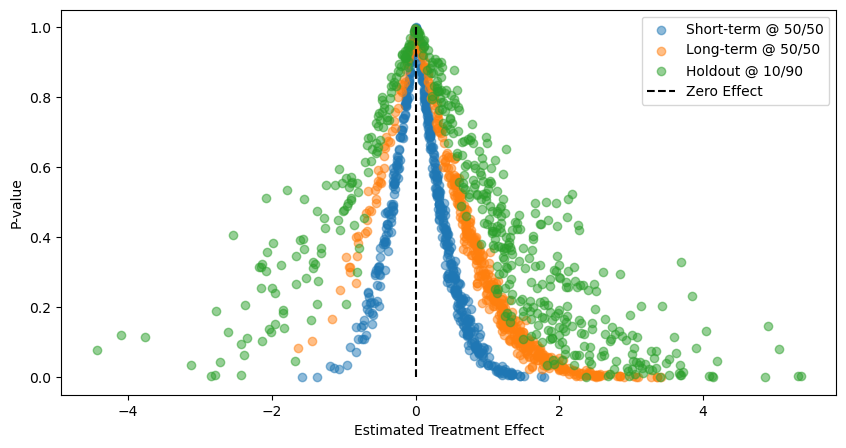

In [125]:
fig,ax = plt.subplots(1,1,figsize=(10,5))
ax.scatter(df_results['diff_1'], df_results['pval_1'], label = 'Short-term @ 50/50', alpha = 0.5)
ax.scatter(df_results['diff_2'], df_results['pval_2'], label = 'Long-term @ 50/50', alpha = 0.5)
ax.scatter(df_results['diff_3'], df_results['pval_3'], label = 'Holdout @ 10/90', alpha = 0.5)
ax.plot([0,0], [0,1], color = 'black', linestyle = '--', label = 'Zero Effect')
ax.set_xlabel('Estimated Treatment Effect')
ax.set_ylabel('P-value')
ax.legend()
plt.show()



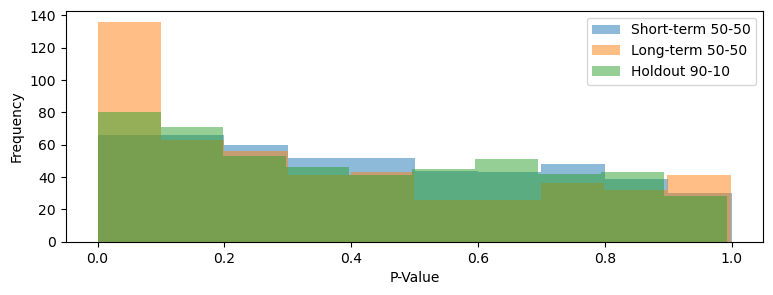

In [111]:

fig,ax = plt.subplots(ncols=1,nrows=1,figsize=(9,3))
ax.hist(df_results['pval_1'], alpha = 0.5, label = 'Short-term 50-50')
ax.hist(df_results['pval_2'], alpha = 0.5, label = 'Long-term 50-50')
ax.hist(df_results['pval_3'], alpha = 0.5, label = 'Holdout 90-10')
ax.set_xlabel('P-Value')
ax.set_ylabel('Frequency')
ax.legend()

plt.show()





